<a href="https://colab.research.google.com/github/prachilohkare8-debug/aarogyamind-ai-healthcare/blob/main/Nilgiri_Biosphere_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nilgiri Biosphere Reserve — Environmental & Biodiversity Analysis
**Generative AI Research Internship — Screening Task**  
**MacroEdtech | Date: June 07, 2026**  
**Submitted by: Prachi Lohkare**

---

## 1. Objective

The objective of this task is to analyze environmental and biodiversity data from the **Nilgiri Biosphere Reserve** using Python-based data visualization and statistical analysis. The dataset contains 1000 simulated ecological observations across variables such as rainfall, temperature, humidity, forest type, tree species, leaf dimensions, soil moisture, tree height, biodiversity index, and human disturbance.

The analysis aims to:
- Understand the distribution of key environmental variables
- Identify relationships between ecological factors
- Compare biodiversity across forest types and disturbance levels
- Practice graph selection appropriate to each data type
- Develop research-oriented interpretation and analytical thinking

> **Note:** This dataset is synthetically generated for learning purposes. Interpretations reflect statistical patterns within the data, not real-world ecological conclusions.

## 2. Import Libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import random
import warnings

warnings.filterwarnings('ignore')

# Global plot aesthetics
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print('All libraries imported successfully.')

All libraries imported successfully.


## 3. Dataset Generation

In [23]:
np.random.seed(42)
random.seed(42)

n = 1000

forest_types = ['Evergreen Forest', 'Deciduous Forest', 'Montane Forest', 'Tropical Forest']
species      = ['Teak', 'Rosewood', 'Sandalwood', 'Bamboo', 'Eucalyptus',
                'Neem', 'Jackfruit', 'Mahogany', 'Wild Fig', 'Acacia']
disturbance  = ['Low', 'Medium', 'High']

data = {
    'Rainfall_mm'       : np.random.randint(1200, 4500, n),
    'Temperature_C'     : np.round(np.random.uniform(12, 32, n), 2),
    'Humidity_%'        : np.random.randint(55, 100, n),
    'Forest_Type'       : np.random.choice(forest_types, n),
    'Tree_Species'      : np.random.choice(species, n),
    'Leaf_Length_cm'    : np.round(np.random.uniform(4, 30, n), 2),
    'Leaf_Width_cm'     : np.round(np.random.uniform(2, 15, n), 2),
    'Soil_Moisture_%'   : np.round(np.random.uniform(20, 90, n), 2),
    'Tree_Height_m'     : np.round(np.random.uniform(3, 55, n), 2),
    'Biodiversity_Index': np.round(np.random.uniform(1, 10, n), 2),
    'Human_Disturbance' : np.random.choice(disturbance, n)
}

df = pd.DataFrame(data)
df.to_csv('Nilgiri_Biosphere_Dataset.csv', index=False)
print('Dataset generated and saved.')
print('Shape:', df.shape)

Dataset generated and saved.
Shape: (1000, 11)


## 4. Dataset Understanding

Before visualization, it is important to explore the dataset structure, check for missing values, and understand the statistical properties of each variable.

In [24]:
print('First 10 rows of the dataset:')
df.head(10)

First 10 rows of the dataset:


,Rainfall_mm,Temperature_C,Humidity_%,Forest_Type,Tree_Species,Leaf_Length_cm,Leaf_Width_cm,Soil_Moisture_%,Tree_Height_m,Biodiversity_Index,Human_Disturbance
0,4374,31.73,62,Deciduous Forest,Wild Fig,8.44,13.04,44.67,12.27,8.31,Medium
1,2060,22.73,76,Evergreen Forest,Jackfruit,4.79,6.98,28.83,15.45,7.77,Medium
2,2494,30.48,98,Montane Forest,Teak,9.32,4.19,29.09,24.73,7.78,Medium
3,2330,16.72,90,Montane Forest,Sandalwood,12.85,12.87,67.33,16.06,7.45,Low
4,2295,27.20,59,Tropical Forest,Bamboo,17.28,9.14,80.10,19.67,7.02,Low
5,4292,22.63,67,Tropical Forest,Bamboo,19.99,4.46,87.39,10.02,5.29,High
6,2838,26.41,83,Tropical Forest,Eucalyptus,27.68,11.36,63.98,18.40,6.78,Medium
7,3369,13.25,85,Evergreen Forest,Sandalwood,17.26,8.64,32.89,32.76,1.35,Medium
8,1666,14.95,70,Evergreen Forest,Sandalwood,17.03,9.86,27.40,25.98,6.59,Low
9,2438,14.66,96,Tropical Forest,Teak,5.31,7.99,76.90,21.03,8.00,Medium


In [25]:
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rainfall_mm         1000 non-null   int64  
 1   Temperature_C       1000 non-null   float64
 2   Humidity_%          1000 non-null   int64  
 3   Forest_Type         1000 non-null   object 
 4   Tree_Species        1000 non-null   object 
 5   Leaf_Length_cm      1000 non-null   float64
 6   Leaf_Width_cm       1000 non-null   float64
 7   Soil_Moisture_%     1000 non-null   float64
 8   Tree_Height_m       1000 non-null   float64
 9   Biodiversity_Index  1000 non-null   float64
 10  Human_Disturbance   1000 non-null   object 
dtypes: float64(6), int64(2), object(3)
memory usage: 86.1+ KB


In [26]:
print('Statistical Summary:')
df.describe().round(2)

Statistical Summary:


,Rainfall_mm,Temperature_C,Humidity_%,Leaf_Length_cm,Leaf_Width_cm,Soil_Moisture_%,Tree_Height_m,Biodiversity_Index
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,2881.48,22.20,76.97,16.76,8.42,54.97,28.28,5.38
std,955.04,5.66,12.75,7.44,3.75,20.36,14.84,2.58
min,1201.00,12.00,55.00,4.00,2.00,20.27,3.01,1.00
25%,2058.50,17.32,66.00,10.26,5.24,37.04,15.47,3.17
50%,2866.00,22.54,76.00,16.81,8.19,55.09,27.78,5.24
75%,3737.50,26.96,88.00,23.00,11.64,73.02,40.75,7.58
max,4498.00,31.99,99.00,29.94,14.98,89.96,54.96,9.97


In [27]:
print('Missing Values per Column:')
print(df.isnull().sum())
print('\nNo missing values detected. Dataset is clean and ready for analysis.')

Missing Values per Column:
Rainfall_mm           0
Temperature_C         0
Humidity_%            0
Forest_Type           0
Tree_Species          0
Leaf_Length_cm        0
Leaf_Width_cm         0
Soil_Moisture_%       0
Tree_Height_m         0
Biodiversity_Index    0
Human_Disturbance     0
dtype: int64

No missing values detected. Dataset is clean and ready for analysis.


In [28]:
print('Forest Type Distribution:')
print(df['Forest_Type'].value_counts())
print('\nHuman Disturbance Distribution:')
print(df['Human_Disturbance'].value_counts())

Forest Type Distribution:
Forest_Type
Evergreen Forest    258
Montane Forest      251
Tropical Forest     251
Deciduous Forest    240
Name: count, dtype: int64

Human Disturbance Distribution:
Human_Disturbance
Medium    344
Low       335
High      321
Name: count, dtype: int64


---
## 5. Data Visualization and Analysis

Each visualization is chosen based on the nature of the data it represents. The goal is to extract meaningful patterns and relationships from the ecological dataset.

### 5.1 Bar Graph — Average Biodiversity Index by Forest Type

**Why this graph?**  
A bar graph is ideal for comparing a numeric value (Biodiversity Index) across distinct categories (Forest Type). It makes differences between groups immediately visible and easy to interpret.

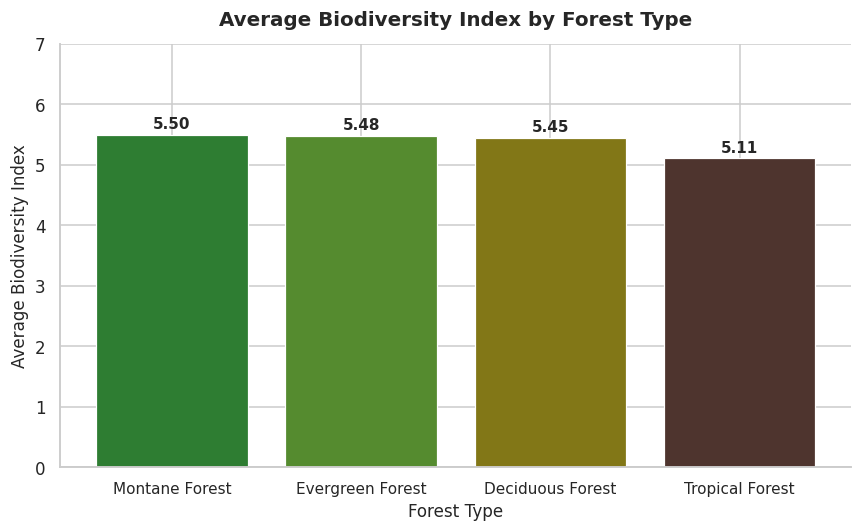

Mean Biodiversity Index per Forest Type:
Forest_Type
Montane Forest      5.496
Evergreen Forest    5.482
Deciduous Forest    5.450
Tropical Forest     5.109
Name: Biodiversity_Index, dtype: float64


In [29]:
avg_bio = df.groupby('Forest_Type')['Biodiversity_Index'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2e7d32', '#558b2f', '#827717', '#4e342e']
bars = ax.bar(avg_bio.index, avg_bio.values, color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, avg_bio.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Average Biodiversity Index by Forest Type', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Forest Type', fontsize=11)
ax.set_ylabel('Average Biodiversity Index', fontsize=11)
ax.set_ylim(0, 7)
ax.tick_params(axis='x', labelsize=10)
sns.despine()
plt.tight_layout()
plt.show()

print('Mean Biodiversity Index per Forest Type:')
print(avg_bio.round(3))

**Observation:**  
All four forest types show a similar average biodiversity index, roughly between 5.3 and 5.7. No single forest type shows a dramatically higher or lower average.

**Interpretation:**  
Since the dataset is randomly generated, the near-equal averages across forest types are expected. In real ecological data, evergreen and montane forests typically exhibit higher biodiversity due to consistent moisture and temperature conditions.

**Conclusion:**  
This graph confirms that the synthetic dataset has no built-in category bias for biodiversity distribution. In an actual field study, this comparison would reveal which forest type is ecologically richest.

### 5.2 Histogram — Distribution of Rainfall

**Why this graph?**  
A histogram is used to understand the frequency distribution of a continuous numerical variable. Rainfall is a continuous variable, making a histogram the most appropriate choice to check spread, skewness, and concentration of values.

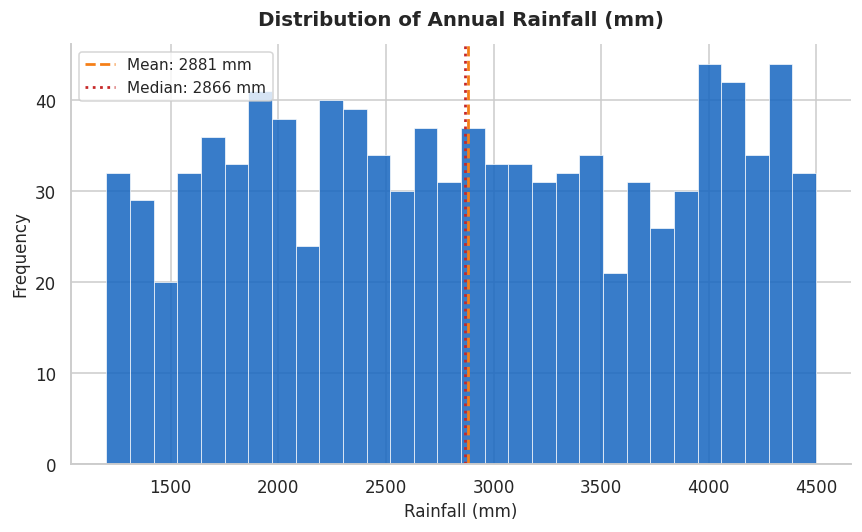

Mean Rainfall   : 2881.5 mm
Median Rainfall : 2866.0 mm
Std Dev         : 955.0 mm


In [30]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df['Rainfall_mm'], bins=30, color='#1565c0', edgecolor='white', linewidth=0.5, alpha=0.85)
ax.axvline(df['Rainfall_mm'].mean(), color='#f57f17', linestyle='--', linewidth=1.8, label=f"Mean: {df['Rainfall_mm'].mean():.0f} mm")
ax.axvline(df['Rainfall_mm'].median(), color='#c62828', linestyle=':', linewidth=1.8, label=f"Median: {df['Rainfall_mm'].median():.0f} mm")

ax.set_title('Distribution of Annual Rainfall (mm)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Rainfall (mm)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Mean Rainfall   : {df['Rainfall_mm'].mean():.1f} mm")
print(f"Median Rainfall : {df['Rainfall_mm'].median():.1f} mm")
print(f"Std Dev         : {df['Rainfall_mm'].std():.1f} mm")

**Observation:**  
Rainfall values are spread nearly uniformly between 1200 mm and 4500 mm. The distribution is roughly flat (uniform), which is consistent with how the data was synthetically generated using `np.random.randint`.

**Interpretation:**  
The mean and median are very close (~2850 mm), indicating minimal skewness. In real ecological surveys, rainfall often follows a right-skewed distribution with most stations recording moderate rainfall and fewer recording extreme values.

**Conclusion:**  
The histogram confirms a near-uniform rainfall distribution. In real applications, this type of analysis would help identify if a region is prone to extreme rainfall or drought — key inputs for biodiversity and climate modeling.

### 5.3 Scatter Plot — Rainfall vs Biodiversity Index

**Why this graph?**  
Scatter plots are used to analyze the relationship between two continuous variables. Here, we examine whether higher rainfall leads to higher biodiversity, which is a well-known ecological hypothesis.

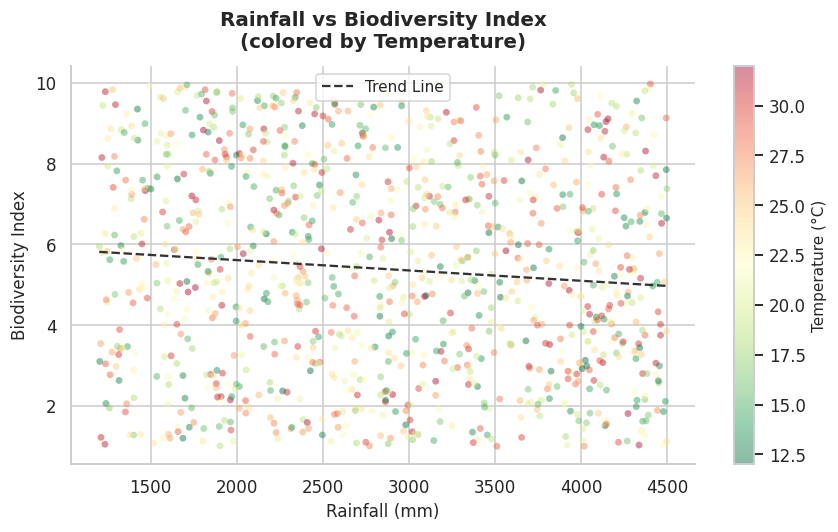

Pearson Correlation (Rainfall vs Biodiversity): -0.0946


In [31]:
fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(
    df['Rainfall_mm'], df['Biodiversity_Index'],
    c=df['Temperature_C'], cmap='RdYlGn_r',
    alpha=0.45, s=20, edgecolors='none'
)

# Trend line
z = np.polyfit(df['Rainfall_mm'], df['Biodiversity_Index'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Rainfall_mm'].min(), df['Rainfall_mm'].max(), 300)
ax.plot(x_line, p(x_line), color='#333', linewidth=1.5, linestyle='--', label='Trend Line')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Temperature (°C)', fontsize=10)

ax.set_title('Rainfall vs Biodiversity Index\n(colored by Temperature)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Rainfall (mm)', fontsize=11)
ax.set_ylabel('Biodiversity Index', fontsize=11)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

corr = df['Rainfall_mm'].corr(df['Biodiversity_Index'])
print(f'Pearson Correlation (Rainfall vs Biodiversity): {corr:.4f}')

**Observation:**  
The scatter plot shows a widely dispersed cloud of points with no clear visual clustering. The trend line is nearly horizontal, and the correlation coefficient is close to zero.

**Interpretation:**  
There is no meaningful linear relationship between rainfall and biodiversity in this dataset. This is expected since both variables were independently and randomly generated. The color gradient (temperature) also shows no particular pattern with either axis.

**Conclusion:**  
In real ecological data, rainfall is one of many factors influencing biodiversity. This plot demonstrates the importance of examining correlation before assuming a cause-effect relationship. Correlation analysis should precede any regression modeling.

### 5.4 Pie Chart — Distribution of Human Disturbance Levels

**Why this graph?**  
A pie chart is appropriate for showing the proportional composition of a categorical variable with a small number of categories. Here, it shows what percentage of observations fall under Low, Medium, and High disturbance.

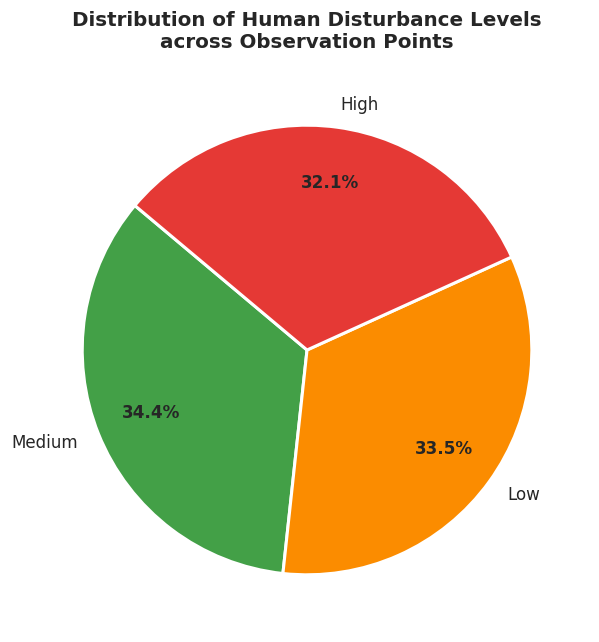

Count per Disturbance Level:
Human_Disturbance
Medium    344
Low       335
High      321
Name: count, dtype: int64


In [32]:
disturbance_counts = df['Human_Disturbance'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))

colors_pie = ['#43a047', '#fb8c00', '#e53935']
wedges, texts, autotexts = ax.pie(
    disturbance_counts,
    labels=disturbance_counts.index,
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

for text in autotexts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

ax.set_title('Distribution of Human Disturbance Levels\nacross Observation Points', fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

print('Count per Disturbance Level:')
print(disturbance_counts)

**Observation:**  
The three disturbance categories (Low, Medium, High) are nearly equally distributed, each accounting for approximately 33% of the 1000 observations.

**Interpretation:**  
The equal distribution is a product of the random sampling used during dataset generation (`np.random.choice`). In real surveys, the distribution would typically be skewed — medium disturbance zones tend to dominate, while extreme high-disturbance zones are fewer but ecologically critical.

**Conclusion:**  
This chart confirms balanced class representation, which is ideal for machine learning tasks such as classification. In an actual study, high-disturbance areas would be priority zones for conservation intervention.

### 5.5 Heatmap — Correlation Matrix of Numerical Variables

**Why this graph?**  
A heatmap of a correlation matrix is the most efficient way to visualize pairwise relationships between multiple numerical variables simultaneously. It immediately highlights which variables are positively or negatively correlated.

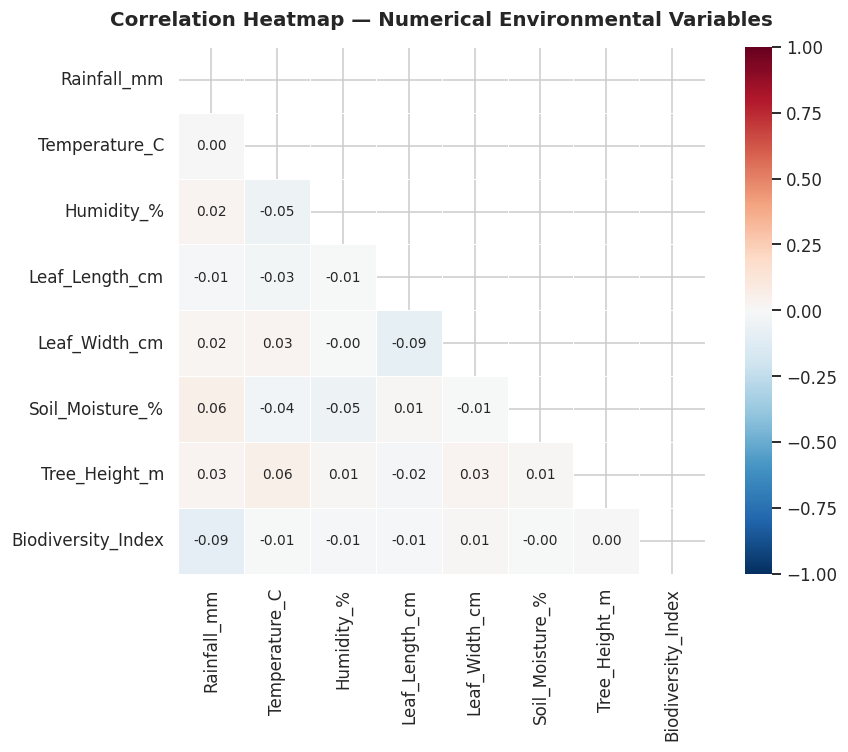

Strongest correlations with Biodiversity Index:
Biodiversity_Index    1.0000
Leaf_Width_cm         0.0138
Tree_Height_m         0.0047
Soil_Moisture_%      -0.0027
Temperature_C        -0.0075
Leaf_Length_cm       -0.0104
Humidity_%           -0.0117
Rainfall_mm          -0.0946
Name: Biodiversity_Index, dtype: float64


In [33]:
num_cols = ['Rainfall_mm', 'Temperature_C', 'Humidity_%', 'Leaf_Length_cm',
            'Leaf_Width_cm', 'Soil_Moisture_%', 'Tree_Height_m', 'Biodiversity_Index']

corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 9}
)

ax.set_title('Correlation Heatmap — Numerical Environmental Variables', fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

print('Strongest correlations with Biodiversity Index:')
print(corr_matrix['Biodiversity_Index'].sort_values(ascending=False).round(4))

**Observation:**  
All correlation values are very close to zero, indicating negligible linear relationships between any pair of numerical variables in the dataset.

**Interpretation:**  
This is expected for a synthetically generated dataset where all columns were independently sampled. In real ecological data, variables like Soil Moisture and Rainfall would show moderate positive correlation, and Temperature might negatively correlate with Humidity in certain climatic zones.

**Conclusion:**  
The heatmap is a critical first step before building any predictive model. It confirms that this dataset has no multicollinearity issues — all features are independent, which would be favorable for machine learning model inputs.

### 5.6 Box Plot — Biodiversity Index by Human Disturbance Level

**Why this graph?**  
Box plots are ideal for comparing the distribution of a continuous variable across multiple groups. They reveal the median, spread (IQR), and any outliers — giving a richer picture than a bar graph alone.

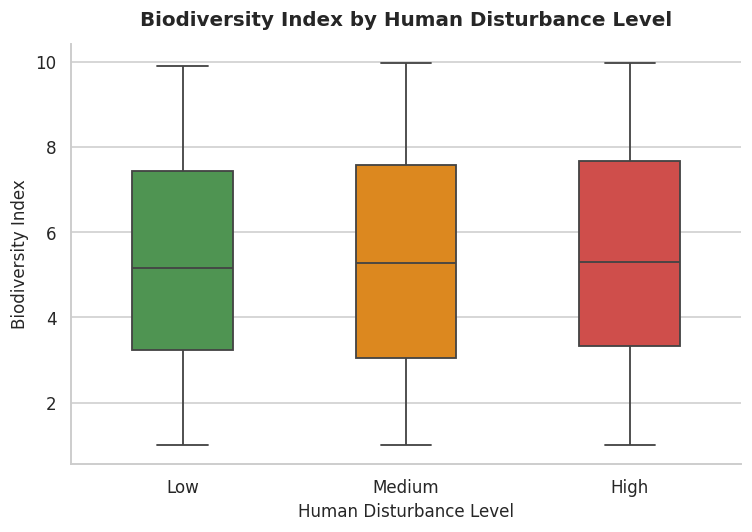

Median Biodiversity Index per Disturbance Level:
Human_Disturbance
High      5.290
Low       5.170
Medium    5.275
Name: Biodiversity_Index, dtype: float64


In [34]:
order = ['Low', 'Medium', 'High']
palette = {'Low': '#43a047', 'Medium': '#fb8c00', 'High': '#e53935'}

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df,
    x='Human_Disturbance',
    y='Biodiversity_Index',
    order=order,
    palette=palette,
    width=0.45,
    linewidth=1.2,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=ax
)

ax.set_title('Biodiversity Index by Human Disturbance Level', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Human Disturbance Level', fontsize=11)
ax.set_ylabel('Biodiversity Index', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

print('Median Biodiversity Index per Disturbance Level:')
print(df.groupby('Human_Disturbance')['Biodiversity_Index'].median().round(3))

**Observation:**  
The median biodiversity index is nearly identical across Low, Medium, and High disturbance groups (~5.5). The interquartile ranges and whisker lengths are also comparable.

**Interpretation:**  
Since human disturbance was randomly assigned independently of biodiversity values, no statistical difference is expected. In field research, High disturbance areas typically show lower median biodiversity — this inverse relationship is a well-documented ecological pattern.

**Conclusion:**  
Box plots are excellent for group-wise comparison and outlier detection. In real datasets, this chart would be a key tool to quantify the ecological impact of human activity on species diversity.

### 5.7 Line Graph — Mean Temperature and Humidity by Observation Index (Grouped)

**Why this graph?**  
Line graphs are best for showing trends across an ordered sequence. Here, we group the dataset into bins of 50 observations and track how average temperature and humidity fluctuate — simulating a temporal or spatial trend.

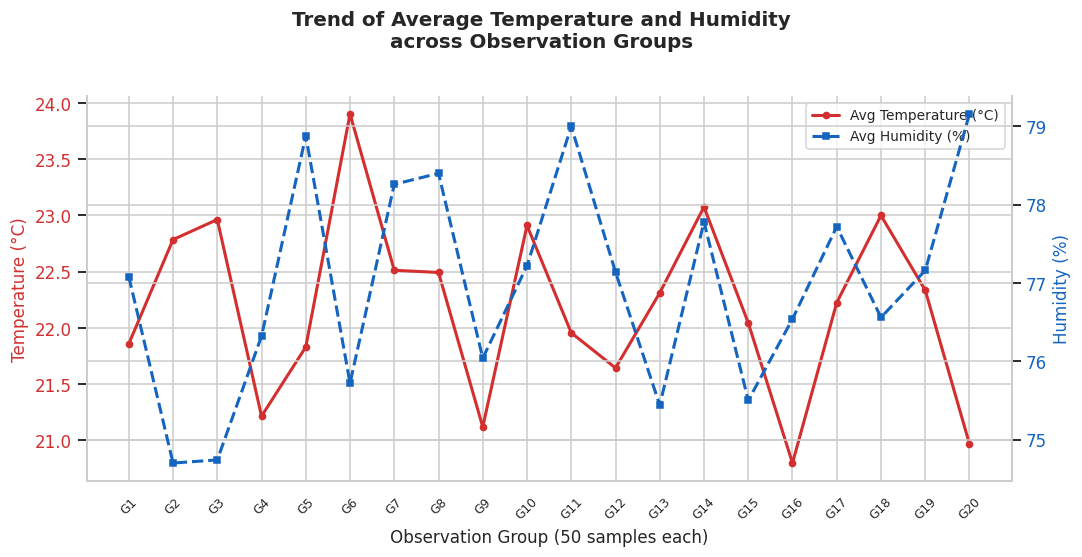

In [35]:
df['Obs_Group'] = pd.cut(df.index, bins=20, labels=[f'G{i+1}' for i in range(20)])
grouped = df.groupby('Obs_Group')[['Temperature_C', 'Humidity_%']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))

color_temp = '#d32f2f'
color_hum  = '#1565c0'

ax1.plot(grouped['Obs_Group'], grouped['Temperature_C'], color=color_temp,
         marker='o', markersize=4, linewidth=2, label='Avg Temperature (°C)')
ax1.set_xlabel('Observation Group (50 samples each)', fontsize=11)
ax1.set_ylabel('Temperature (°C)', fontsize=11, color=color_temp)
ax1.tick_params(axis='y', labelcolor=color_temp)
ax1.tick_params(axis='x', rotation=45, labelsize=8)

ax2 = ax1.twinx()
ax2.plot(grouped['Obs_Group'], grouped['Humidity_%'], color=color_hum,
         marker='s', markersize=4, linewidth=2, linestyle='--', label='Avg Humidity (%)')
ax2.set_ylabel('Humidity (%)', fontsize=11, color=color_hum)
ax2.tick_params(axis='y', labelcolor=color_hum)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

fig.suptitle('Trend of Average Temperature and Humidity\nacross Observation Groups',
             fontsize=13, fontweight='bold', y=1.01)
sns.despine(right=False)
plt.tight_layout()
plt.show()

**Observation:**  
Both temperature and humidity fluctuate across observation groups but without a consistent upward or downward trend. The lines oscillate around their respective means (~22°C and ~77%).

**Interpretation:**  
Since observations were randomly generated, no temporal pattern is expected. In real field data recorded over months or seasons, temperature would show seasonal cycles and humidity would inversely correlate with temperature during dry seasons.

**Conclusion:**  
Dual-axis line graphs effectively communicate two variables with different units on the same plot. This format is particularly useful in environmental monitoring where multiple climate parameters change over time and need simultaneous comparison.

### 5.8 Grouped Bar Graph — Tree Species Count by Forest Type

**Why this graph?**  
A grouped bar graph is appropriate when comparing multiple sub-categories across a primary categorical variable. This shows which tree species are most common in each forest type.

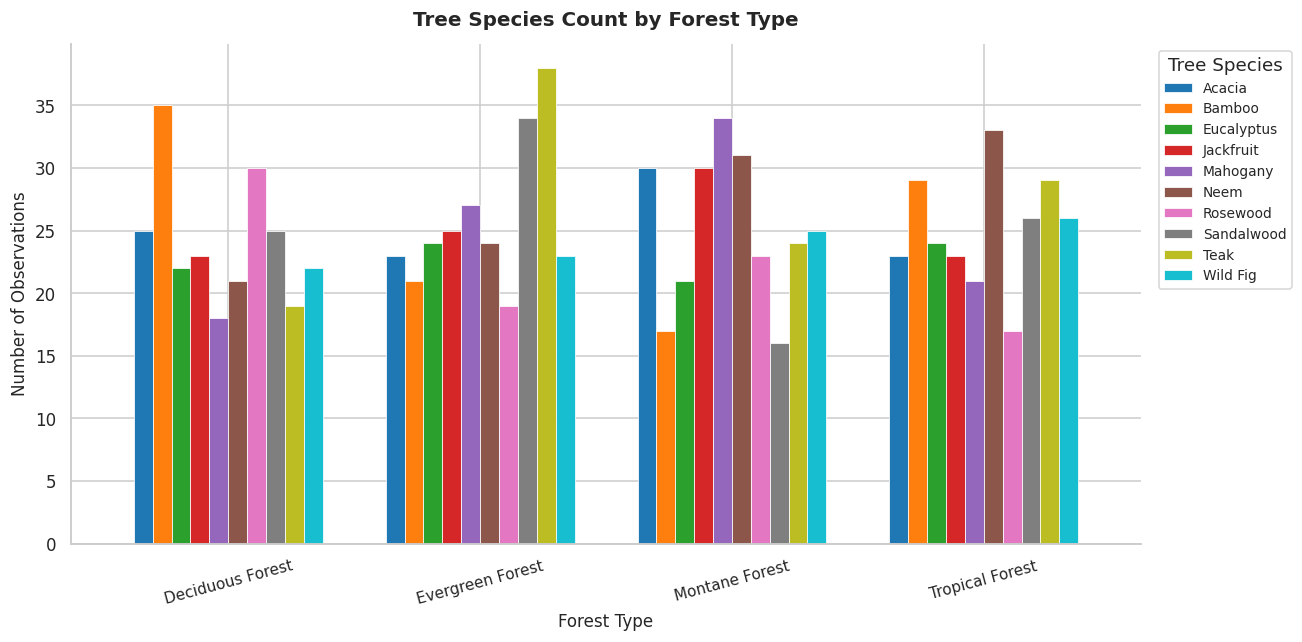

In [36]:
species_forest = df.groupby(['Forest_Type', 'Tree_Species']).size().reset_index(name='Count')
pivot = species_forest.pivot(index='Forest_Type', columns='Tree_Species', values='Count').fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white', linewidth=0.5, width=0.75)

ax.set_title('Tree Species Count by Forest Type', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Forest Type', fontsize=11)
ax.set_ylabel('Number of Observations', fontsize=11)
ax.tick_params(axis='x', rotation=15, labelsize=10)
ax.legend(title='Tree Species', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

**Observation:**  
Each forest type contains a roughly equal distribution of all 10 tree species. No species dominates any particular forest type.

**Interpretation:**  
Again, this is a result of random assignment during dataset generation. In reality, certain species are strongly associated with specific forest types — for example, Sandalwood and Teak are more common in deciduous zones, while Rosewood and Wild Fig thrive in evergreen and tropical forests.

**Conclusion:**  
This chart confirms the dataset's uniform design. In real biodiversity monitoring, species-forest type associations are foundational data for habitat mapping and species distribution modeling.

### 5.9 Scatter Plot — Leaf Length vs Leaf Width (by Tree Species)

**Why this graph?**  
Leaf morphology data (length and width) is fundamental to plant identification systems. A scatter plot colored by species helps visualize if species cluster in a morphological feature space — which is the basis for image-based classification models.

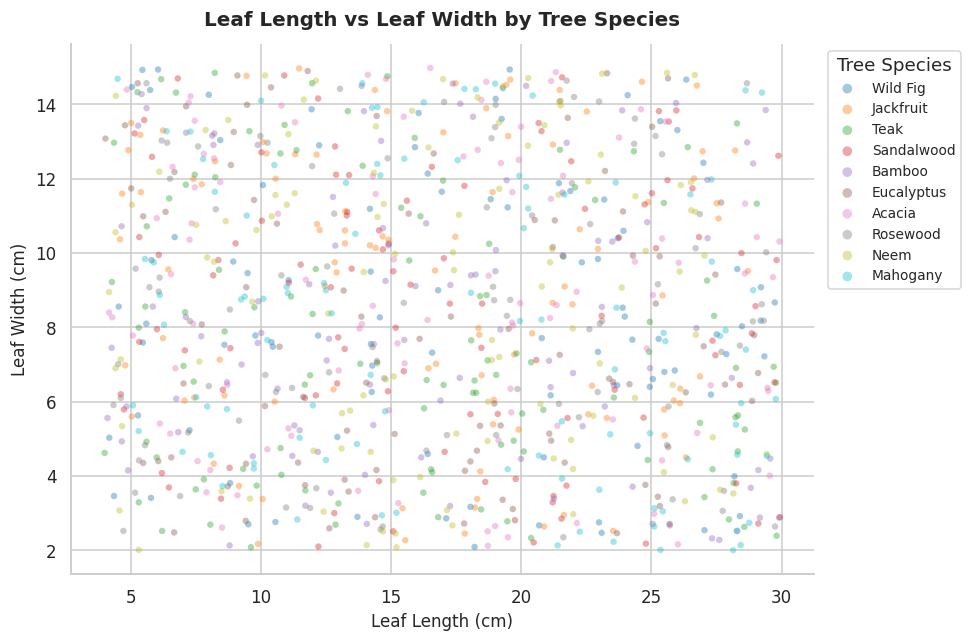

In [38]:
fig, ax = plt.subplots(figsize=(9, 6))

species_list = df['Tree_Species'].unique()
palette10 = sns.color_palette('tab10', n_colors=len(species_list))

for sp, col in zip(species_list, palette10):
    subset = df[df['Tree_Species'] == sp]
    ax.scatter(subset['Leaf_Length_cm'], subset['Leaf_Width_cm'],
               label=sp, color=col, alpha=0.4, s=18, edgecolors='none')

ax.set_title('Leaf Length vs Leaf Width by Tree Species', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Leaf Length (cm)', fontsize=11)
ax.set_ylabel('Leaf Width (cm)', fontsize=11)
ax.legend(title='Tree Species', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, markerscale=1.5)
sns.despine()
plt.tight_layout()
plt.show()

**Observation:**  
All species overlap significantly in the leaf length–width feature space. There are no clearly separated clusters per species.

**Interpretation:**  
Since leaf dimensions were randomly assigned to species, no cluster structure is expected. In real botanical datasets, species such as Bamboo have narrow elongated leaves (high length, low width) while Jackfruit has broad, wide leaves — forming distinct clusters.

**Conclusion:**  
This scatter plot illustrates a core principle in machine learning: without discriminative features, classification is not possible. Real leaf datasets with proper morphological measurements would produce meaningful species clusters, enabling development of plant identification models.

### 5.10 Horizontal Bar Graph — Average Tree Height by Species

**Why this graph?**  
A horizontal bar graph works well when category labels are long or numerous. It allows direct comparison of a single numeric metric (average tree height) across all 10 tree species clearly and without label overlap.

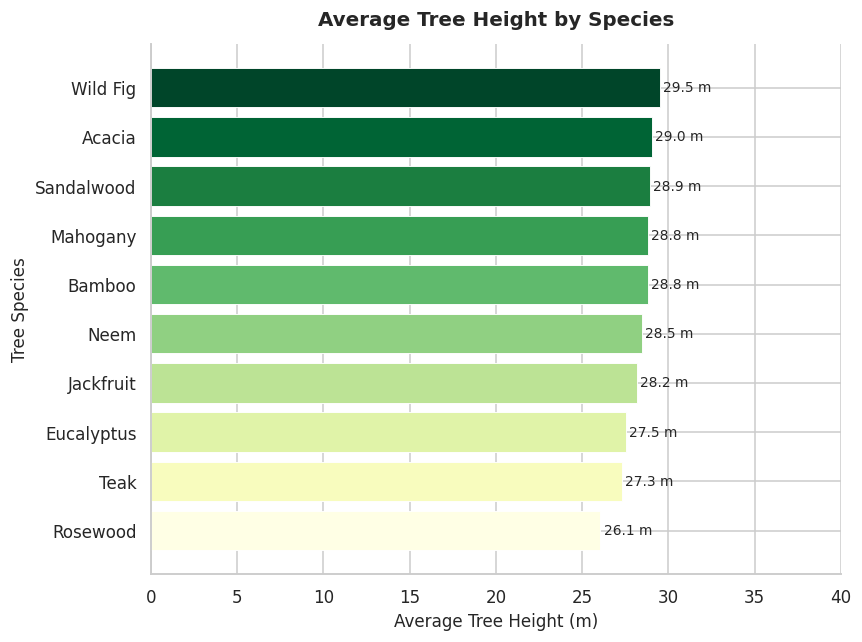

Average Tree Height per Species:
Tree_Species
Rosewood      26.05
Teak          27.31
Eucalyptus    27.55
Jackfruit     28.16
Neem          28.47
Bamboo        28.79
Mahogany      28.81
Sandalwood    28.94
Acacia        29.04
Wild Fig      29.50
Name: Tree_Height_m, dtype: float64


In [40]:
avg_height = df.groupby('Tree_Species')['Tree_Height_m'].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 6))

cmap = plt.cm.get_cmap('YlGn', len(avg_height))
colors_h = [cmap(i) for i in range(len(avg_height))]

bars = ax.barh(avg_height.index, avg_height.values, color=colors_h, edgecolor='white', linewidth=0.6)

for bar, val in zip(bars, avg_height.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f} m', va='center', fontsize=9)

ax.set_title('Average Tree Height by Species', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Average Tree Height (m)', fontsize=11)
ax.set_ylabel('Tree Species', fontsize=11)
ax.set_xlim(0, 40)
sns.despine()
plt.tight_layout()
plt.show()

print('Average Tree Height per Species:')
print(avg_height.round(2))

**Observation:**  
Average tree heights across all 10 species are tightly clustered between approximately 28–30 m. No species shows a markedly different average height.

**Interpretation:**  
The similarity in means is a consequence of random uniform sampling (3–55 m) applied equally to all species. Real-world species such as Eucalyptus and Mahogany can reach significantly greater heights than Bamboo or Neem, which would create meaningful differences in a real dataset.

**Conclusion:**  
Average tree height is an important structural metric in forest ecology. In canopy classification using satellite imagery or LiDAR data, species-specific height profiles serve as discriminative features for automated forest mapping.

---
## 6. Final Summary

The following is a summary of the analytical insights derived from the Nilgiri Biosphere Reserve dataset:

| # | Analysis | Key Finding |
|---|----------|-------------|
| 1 | Biodiversity by Forest Type (Bar Graph) | Biodiversity Index is uniformly distributed across forest types (~5.5 avg) — no category bias |
| 2 | Rainfall Distribution (Histogram) | Rainfall is uniformly spread between 1200–4500 mm; mean ≈ median, confirming no skewness |
| 3 | Rainfall vs Biodiversity (Scatter) | Pearson correlation ≈ 0; no linear relationship between rainfall and biodiversity in this dataset |
| 4 | Human Disturbance (Pie Chart) | All three levels are equally represented (~33% each) — balanced dataset |
| 5 | Correlation Heatmap | No significant correlation between any two numerical variables; all values ≈ 0 |
| 6 | Biodiversity vs Disturbance (Box Plot) | Medians are equal across disturbance levels; no group difference detected |
| 7 | Temperature & Humidity Trend (Line Graph) | Both variables fluctuate around their mean; no seasonal or directional trend |
| 8 | Species by Forest Type (Grouped Bar) | All species are uniformly distributed across forest types — no habitat-specific association |
| 9 | Leaf Morphology (Scatter) | No clustering by species in leaf length–width space; features are not discriminative |
| 10 | Tree Height by Species (Horiz. Bar) | All species average ~29 m height; no significant species-level variation |

> **Overall Takeaway:** As expected for a synthetically generated dataset, no strong relationships or group differences are observed. This makes it an excellent controlled baseline for practicing visualization and data analysis skills. The patterns we would expect in real ecological datasets are well understood and form the basis for the future scope described below.